# 실습 목표
1. Object detection 모델을 학습할 수 있습니다.
2. RetinaNet 모델을 활용한 시스템을 만들 수 있습니다.
# 학습 내용
- 자율주행 보조장치
- RetinaNet
- 데이터 준비부터 모델 학습, 결과 확인까지
- 프로젝트: 자율주행 보조 시스템 만들기
# 준비물
아직 경로를 생성하지 않았다면 터미널을 열고 개인 실습 환경에 따라 경로를 수정, 프로젝트를 위한 디렉토리를 생성해 주세요.

# 2. 자율주행 보조장치
## (1) KITTI 데이터셋
이번 시간에 만들어 볼 자율주행 보조장치는 카메라에 사람이 탐지되었을 때, 그리고 차가 가까워져서 탐지된 크기가 일정 크기 이상일 때를 판단해야 합니다.

자율주행 보조장치 object detection 요구사항

사람이 카메라에 감지되면 정지
차량이 일정 크기 이상으로 감지되면 정지

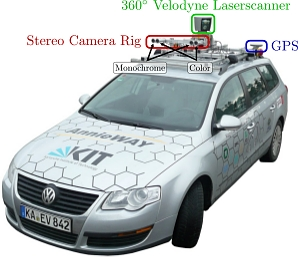

이번 시간에는 tensorflow_datasets에서 제공하는 KITTI 데이터셋을 사용해보겠습니다. KITTI 데이터셋은 자율주행을 위한 데이터셋으로 2D object detection 뿐만 아니라 깊이까지 포함한 3D object detection 라벨 등을 제공하고 있습니다.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as TF
from torchvision import transforms
from torchvision.datasets import Kitti
import torchvision.models as models
from torchvision.ops import nms

import os, copy, time
import numpy as np
import random
from typing import Dict, List, Tuple, Optional, Callable
import argparse
from tqdm import tqdm

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

print('슝=3')

슝=3
